In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Lectura de archivos

clientes = pd.read_csv("../data/clientes_loyalty.csv")
promociones = pd.read_csv("../data/promociones_activas.csv")
transacciones = pd.read_csv("../data/transacciones_resumen.csv")
variables_exogenas = pd.read_csv("../data/variables_exogenas.csv")

In [4]:
# Validación de carga de archivos

print("Clientes:")
print(clientes.shape)
display(clientes.head())

print("Promociones:")
print(promociones.shape)
display(promociones.head())

print("Transacciones:")
print(transacciones.shape)
display(transacciones.head())

print("Variables exógenas:")
print(variables_exogenas.shape)
display(variables_exogenas.head())


Clientes:
(1000, 4)


,id_cliente,fecha_registro,edad,segmento
0,CUST_00001,2023-04-30,51,Regular
1,CUST_00002,2023-10-17,22,Budget
2,CUST_00003,2023-06-09,57,Regular
3,CUST_00004,2022-08-31,20,Budget
4,CUST_00005,2023-11-13,19,Budget


Promociones:
(493, 5)


,fecha_inicio,fecha_fin,id_producto,tipo_descuento,id_tienda
0,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,STORE_06
1,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,STORE_08
2,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,STORE_10
3,2024-02-18,2024-02-22,PROD_031,Fixed_Amount,STORE_03
4,2024-02-18,2024-02-22,PROD_031,Fixed_Amount,STORE_09


Transacciones:
(10000, 6)


,id_ticket,id_tienda,timestamp,total_venta,total_articulos,id_cliente
0,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647
1,TICKET_0000002,STORE_05,2024-03-22 13:51:00,38.40,4,CUST_00500
2,TICKET_0000003,STORE_07,2024-02-18 13:00:00,41.32,4,CUST_00977
3,TICKET_0000004,STORE_03,2024-02-23 19:39:00,2.97,1,CUST_00866
4,TICKET_0000005,STORE_05,2024-03-06 11:42:00,23.95,2,CUST_00846


Variables exógenas:
(910, 5)


,fecha,id_tienda,clima,competitor_price_index,indice_trafico
0,2024-01-01,STORE_01,Sunny,1.01,85.6
1,2024-01-01,STORE_02,Sunny,1.01,49.5
2,2024-01-01,STORE_03,Sunny,1.03,55.2
3,2024-01-01,STORE_04,Sunny,1.00,80.6
4,2024-01-01,STORE_05,Sunny,0.99,83.0


In [5]:
# Validación de columnas

print("Clientes")
print(clientes.columns)

print("\nPromociones")
print(promociones.columns)

print("\nTransacciones")
print(transacciones.columns)

print("\nVariables exógenas")
print(variables_exogenas.columns)

Clientes
Index(['id_cliente', 'fecha_registro', 'edad', 'segmento'], dtype='str')

Promociones
Index(['fecha_inicio', 'fecha_fin', 'id_producto', 'tipo_descuento',
       'id_tienda'],
      dtype='str')

Transacciones
Index(['id_ticket', 'id_tienda', 'timestamp', 'total_venta', 'total_articulos',
       'id_cliente'],
      dtype='str')

Variables exógenas
Index(['fecha', 'id_tienda', 'clima', 'competitor_price_index',
       'indice_trafico'],
      dtype='str')


In [6]:
# Ajustar formato de fechas
transacciones["timestamp"] = pd.to_datetime(transacciones["timestamp"])
transacciones["fecha"] = transacciones["timestamp"].dt.date
transacciones["fecha"] = pd.to_datetime(transacciones["fecha"])

promociones["fecha_inicio"] = pd.to_datetime(promociones["fecha_inicio"])
promociones["fecha_fin"] = pd.to_datetime(promociones["fecha_fin"])

variables_exogenas["fecha"] = pd.to_datetime(variables_exogenas["fecha"])

clientes["fecha_registro"] = pd.to_datetime(clientes["fecha_registro"])

In [7]:
# Crear métricas de valor para Ticket Promedio

metricas_cliente = transacciones.groupby("id_cliente").agg({
    "total_venta": ["mean", "sum", "count"],
    "total_articulos": "mean"
})

metricas_cliente.columns = [
    "ticket_promedio_cliente",
    "gasto_total_cliente",
    "cantidad_compras",
    "promedio_articulos"
]

metricas_cliente = metricas_cliente.reset_index()

transacciones = transacciones.merge(
    metricas_cliente,
    on="id_cliente",
    how="left"
)

Métricas creadas: 

ticket_promedio_cliente: Promedio histórico de gasto.

gasto_total_cliente: Valor acumulado histórico.

cantidad_compras: Frecuencia de compra.

promedio_articulos: Tamaño promedio de la compra.

In [8]:
# Identificar variable objetivo

transacciones["ticket_promedio"] = transacciones["total_venta"]
print(transacciones.shape)
print(transacciones.head())

(10000, 12)
        id_ticket id_tienda           timestamp  total_venta  total_articulos  \
0  TICKET_0000001  STORE_10 2024-03-31 14:27:00         3.61                1   
1  TICKET_0000002  STORE_05 2024-03-22 13:51:00        38.40                4   
2  TICKET_0000003  STORE_07 2024-02-18 13:00:00        41.32                4   
3  TICKET_0000004  STORE_03 2024-02-23 19:39:00         2.97                1   
4  TICKET_0000005  STORE_05 2024-03-06 11:42:00        23.95                2   

   id_cliente      fecha  ticket_promedio_cliente  gasto_total_cliente  \
0  CUST_00647 2024-03-31                11.890000               154.57   
1  CUST_00500 2024-03-22                31.887619               669.64   
2  CUST_00977 2024-02-18                29.705385               386.17   
3  CUST_00866 2024-02-23                16.255000                65.02   
4  CUST_00846 2024-03-06                17.024444               153.22   

   cantidad_compras  promedio_articulos  ticket_promedio

In [9]:
# Unir datasets (llaves foráneas) + Validación

df = transacciones.copy()

# CLIENTES
df = df.merge(
    clientes,
    on="id_cliente",
    how="left"
)

#PROMOCIONES
df = df.merge(
    promociones,
    on="id_tienda",
    how="left"
)

#VARIABLES EXÓGENAS
df = df.merge(
    variables_exogenas,
    on="id_tienda",
    how="left"
)


# Validar unión de datasets
print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

Dimensiones del dataset:
(44839886, 23)

Primeras filas:


,id_ticket,id_tienda,timestamp,total_venta,total_articulos,id_cliente,fecha_x,ticket_promedio_cliente,gasto_total_cliente,cantidad_compras,...,edad,segmento,fecha_inicio,fecha_fin,id_producto,tipo_descuento,fecha_y,clima,competitor_price_index,indice_trafico
0,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647,2024-03-31,11.89,154.57,13,...,19,Budget,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,2024-01-01,Sunny,1.05,61.2
1,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647,2024-03-31,11.89,154.57,13,...,19,Budget,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,2024-01-02,Cloudy,1.00,41.8
2,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647,2024-03-31,11.89,154.57,13,...,19,Budget,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,2024-01-03,Sunny,0.94,56.4
3,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647,2024-03-31,11.89,154.57,13,...,19,Budget,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,2024-01-04,Rainy,1.04,42.6
4,TICKET_0000001,STORE_10,2024-03-31 14:27:00,3.61,1,CUST_00647,2024-03-31,11.89,154.57,13,...,19,Budget,2024-02-07,2024-02-18,PROD_034,Fixed_Amount,2024-01-05,Sunny,1.01,52.6


In [10]:
# Crear columna fecha a partir de timestamp

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["fecha"] = df["timestamp"].dt.date

df["fecha"] = pd.to_datetime(df["fecha"])


print(df[["timestamp", "fecha"]].head())

            timestamp      fecha
0 2024-03-31 14:27:00 2024-03-31
1 2024-03-31 14:27:00 2024-03-31
2 2024-03-31 14:27:00 2024-03-31
3 2024-03-31 14:27:00 2024-03-31
4 2024-03-31 14:27:00 2024-03-31


In [11]:
# Confirmación del total de datos

print("Cantidad de filas:")
print(len(df))

print("\nTickets únicos:")
print(df["id_ticket"].nunique())

Cantidad de filas:
44839886

Tickets únicos:
10000


In [12]:
# Eliminar duplicados - Mantener solo un registro por ticket

df = df.drop_duplicates(
    subset="id_ticket"
)

print(df.shape)

(10000, 24)


In [13]:
# revisar valores nulos

df.isnull().sum().sort_values(ascending=False)

id_ticket                  0
id_tienda                  0
timestamp                  0
total_venta                0
total_articulos            0
id_cliente                 0
fecha_x                    0
ticket_promedio_cliente    0
gasto_total_cliente        0
cantidad_compras           0
promedio_articulos         0
ticket_promedio            0
fecha_registro             0
edad                       0
segmento                   0
fecha_inicio               0
fecha_fin                  0
id_producto                0
tipo_descuento             0
fecha_y                    0
clima                      0
competitor_price_index     0
indice_trafico             0
fecha                      0
dtype: int64

In [14]:
# Separar variable target y variables predictoras


y = df["ticket_promedio"]


columnas_eliminar = [
    
    # Target relacionado directamente
    "ticket_promedio",
    "total_venta",
    
    # Identificadores
    "id_ticket",
    "id_cliente",
    
    # Timestamp original
    "timestamp"
]


X = df.drop(
    columns=columnas_eliminar,
    errors="ignore"
)

print(X.head())

      id_tienda  total_articulos    fecha_x  ticket_promedio_cliente  \
0      STORE_10                1 2024-03-31                11.890000   
4459   STORE_05                4 2024-03-22                31.887619   
8190   STORE_07                4 2024-02-18                29.705385   
13013  STORE_03                1 2024-02-23                16.255000   
18564  STORE_05                2 2024-03-06                17.024444   

       gasto_total_cliente  cantidad_compras  promedio_articulos  \
0                   154.57                13            1.538462   
4459                669.64                21            3.857143   
8190                386.17                13            3.769231   
13013                65.02                 4            2.250000   
18564               153.22                 9            1.888889   

      fecha_registro  edad segmento fecha_inicio  fecha_fin id_producto  \
0         2022-12-27    19   Budget   2024-02-07 2024-02-18    PROD_034   
4459    

In [15]:
# Eliminar IDs categóricos 

X = X.drop(
    columns=[
        "id_producto",
        "id_tienda"
    ],
    errors="ignore"
)

In [16]:
#Convertir variables categóricas a dummies

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(10000, 18)


In [17]:
#Revisión de datos

print(X.dtypes)

total_articulos                         int64
fecha_x                         datetime64[s]
ticket_promedio_cliente               float64
gasto_total_cliente                   float64
cantidad_compras                        int64
promedio_articulos                    float64
fecha_registro                 datetime64[us]
edad                                    int64
fecha_inicio                   datetime64[us]
fecha_fin                      datetime64[us]
fecha_y                        datetime64[us]
competitor_price_index                float64
indice_trafico                        float64
fecha                           datetime64[s]
segmento_Premium                         bool
segmento_Regular                         bool
tipo_descuento_Fixed_Amount              bool
tipo_descuento_Percentage                bool
dtype: object


In [18]:
# Eliminar columnas de fecha

columnas_fecha = X.select_dtypes(
    include=["datetime64[ns]"]
).columns

print("Columnas fecha encontradas:")
print(columnas_fecha)


X = X.drop(
    columns=columnas_fecha,
    errors="ignore"
)

Columnas fecha encontradas:
Index(['fecha_x', 'fecha_registro', 'fecha_inicio', 'fecha_fin', 'fecha_y',
       'fecha'],
      dtype='str')


In [19]:
# Creación de variables temporales

if "fecha" in df.columns:
    
    X["mes"] = pd.to_datetime(df["fecha"]).dt.month
    X["dia_semana"] = pd.to_datetime(df["fecha"]).dt.dayofweek

print(X.head())

       total_articulos  ticket_promedio_cliente  gasto_total_cliente  \
0                    1                11.890000               154.57   
4459                 4                31.887619               669.64   
8190                 4                29.705385               386.17   
13013                1                16.255000                65.02   
18564                2                17.024444               153.22   

       cantidad_compras  promedio_articulos  edad  competitor_price_index  \
0                    13            1.538462    19                    1.05   
4459                 21            3.857143    57                    0.99   
8190                 13            3.769231    46                    0.85   
13013                 4            2.250000    25                    1.03   
18564                 9            1.888889    25                    0.99   

       indice_trafico  segmento_Premium  segmento_Regular  \
0                61.2             False    

In [20]:
# Imputación de nulos

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(X.head())

   total_articulos  ticket_promedio_cliente  gasto_total_cliente  \
0              1.0                11.890000               154.57   
1              4.0                31.887619               669.64   
2              4.0                29.705385               386.17   
3              1.0                16.255000                65.02   
4              2.0                17.024444               153.22   

   cantidad_compras  promedio_articulos  edad  competitor_price_index  \
0              13.0            1.538462  19.0                    1.05   
1              21.0            3.857143  57.0                    0.99   
2              13.0            3.769231  46.0                    0.85   
3               4.0            2.250000  25.0                    1.03   
4               9.0            1.888889  25.0                    0.99   

   indice_trafico  segmento_Premium  segmento_Regular  \
0            61.2               0.0               0.0   
1            83.0               1.0   

In [21]:
print(df.shape)

(10000, 24)


In [22]:
# División dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 14)
(2000, 14)


In [23]:
# Modelo Random Forest - entrenamiento

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
# Revisión de predicciones en entrenamiento

predicciones = modelo_rf.predict(X_test)

In [25]:
# Evaluar el modelo a través dde las métricas

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 4.36053126010484
RMSE: 5.542446193726802
R2: 0.7557405560267768


In [26]:
# Importancia de variables

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias_filtradas = importancias[
    importancias["Importancia"] > 0.001
]


importancias_filtradas["Importancia"] = (
    importancias_filtradas["Importancia"]
    .round(4)
)


display(importancias_filtradas)

,Variable,Importancia
0,total_articulos,0.8632
1,ticket_promedio_cliente,0.0367
4,promedio_articulos,0.0279
5,edad,0.0138
2,gasto_total_cliente,0.0137
13,dia_semana,0.0115
7,indice_trafico,0.0096
6,competitor_price_index,0.0092
12,mes,0.0058
3,cantidad_compras,0.0052


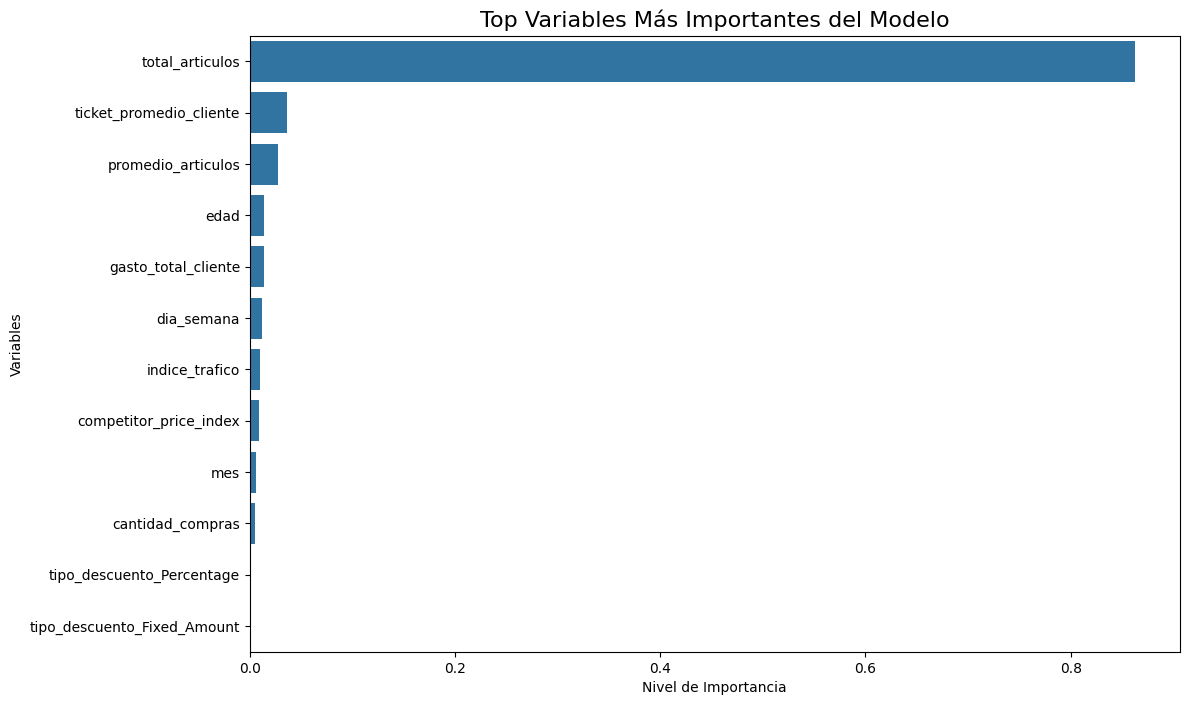

In [27]:
# Graficar importancia de variables

top_variables = importancias_filtradas.head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_variables,
    x="Importancia",
    y="Variable"
)

plt.title(
    "Top Variables Más Importantes del Modelo",
    fontsize=16
)

plt.xlabel("Nivel de Importancia")
plt.ylabel("Variables")

plt.show()

COMPARATIVO ENTR EMODELOS

In [28]:
from sklearn.model_selection import GridSearchCV

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

In [29]:
# Creación de dataframe para resultados de modelos

resultados_modelos = pd.DataFrame(
    columns=[
        "Modelo",
        "MAE",
        "RMSE",
        "R2"
    ]
)

resultados_modelos

,Modelo,MAE,RMSE,R2


In [30]:
# RANDOM FOREST BASE

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)


mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

r2_rf = r2_score(y_test, pred_rf)



resultados_modelos.loc[len(resultados_modelos)] = [
    "Random Forest",
    mae_rf,
    rmse_rf,
    r2_rf
]

resultados_modelos

,Modelo,MAE,RMSE,R2
0,Random Forest,4.360531,5.542446,0.755741


In [31]:
# GRID SEARCH RANDOM FOREST

parametros_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}


grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=parametros_rf,
    cv=3,
    scoring="r2",
    n_jobs=-1
)



grid_rf.fit(X_train, y_train)


mejor_rf = grid_rf.best_estimator_

pred_grid = mejor_rf.predict(X_test)


mae_grid = mean_absolute_error(y_test, pred_grid)

rmse_grid = np.sqrt(
    mean_squared_error(y_test, pred_grid)
)

r2_grid = r2_score(y_test, pred_grid)


resultados_modelos.loc[len(resultados_modelos)] = [
    "GridSearch RF",
    mae_grid,
    rmse_grid,
    r2_grid
]


print("Mejores parámetros:")
print(grid_rf.best_params_)

resultados_modelos

Mejores parámetros:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


,Modelo,MAE,RMSE,R2
0,Random Forest,4.360531,5.542446,0.755741
1,GridSearch RF,4.285521,5.440557,0.764639


In [32]:
# MODELO XGBOOST

modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)



modelo_xgb.fit(X_train, y_train)


pred_xgb = modelo_xgb.predict(X_test)


mae_xgb = mean_absolute_error(y_test, pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2_xgb = r2_score(y_test, pred_xgb)



resultados_modelos.loc[len(resultados_modelos)] = [
    "XGBoost",
    mae_xgb,
    rmse_xgb,
    r2_xgb
]

resultados_modelos

,Modelo,MAE,RMSE,R2
0,Random Forest,4.360531,5.542446,0.755741
1,GridSearch RF,4.285521,5.440557,0.764639
2,XGBoost,4.356457,5.569630,0.753339


In [33]:
# MODELO LIGHTGBM

modelo_lgbm = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)


modelo_lgbm.fit(X_train, y_train)


pred_lgbm = modelo_lgbm.predict(X_test)


mae_lgbm = mean_absolute_error(y_test, pred_lgbm)

rmse_lgbm = np.sqrt(
    mean_squared_error(y_test, pred_lgbm)
)

r2_lgbm = r2_score(y_test, pred_lgbm)


resultados_modelos.loc[len(resultados_modelos)] = [
    "LightGBM",
    mae_lgbm,
    rmse_lgbm,
    r2_lgbm
]

resultados_modelos

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 14
[LightGBM] [Info] Start training from score 17.956225
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Modelo,MAE,RMSE,R2
0,Random Forest,4.360531,5.542446,0.755741
1,GridSearch RF,4.285521,5.440557,0.764639
2,XGBoost,4.356457,5.569630,0.753339
3,LightGBM,4.317119,5.502695,0.759232


In [ ]:
# Resultados consolidados de los Modelos x R2

resultados_modelos = resultados_modelos.round(4)


resultados_modelos = resultados_modelos.sort_values(
    by="R2",
    ascending=False
)


display(resultados_modelos)

,Modelo,MAE,RMSE,R2
1,GridSearch RF,4.2855,5.4406,0.7646
3,LightGBM,4.3171,5.5027,0.7592
0,Random Forest,4.3605,5.5424,0.7557
2,XGBoost,4.3565,5.5696,0.7533


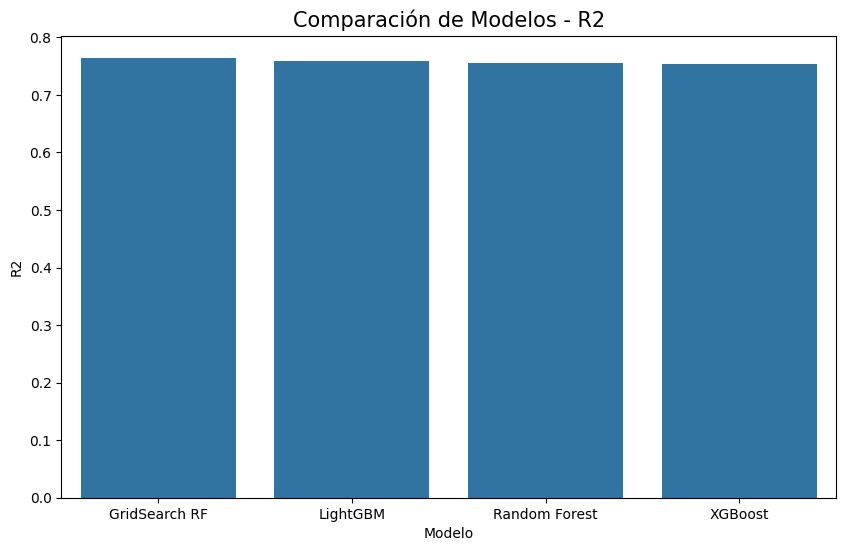

In [35]:
# Gr´afico comparativo R2

plt.figure(figsize=(10,6))

sns.barplot(
    data=resultados_modelos,
    x="Modelo",
    y="R2"
)

plt.title(
    "Comparación de Modelos - R2",
    fontsize=15
)

plt.show()

El modelo que presentó el mejor desempeño fue GridSearch Random Forest, ya que obtuvo el menor error promedio entre todos los modelos evaluados, con un MAE de 4.2855 y un RMSE de 5.4406, lo que indica una mayor precisión en la predicción del ticket promedio de los clientes. Adicionalmente, alcanzó el mayor coeficiente de determinación (R² = 0.7646), evidenciando una mejor capacidad explicativa sobre la variabilidad del gasto de los clientes.

Estos resultados sugieren que el modelo optimizado mediante GridSearchCV logró una mejor generalización frente a datos no observados